# 1. Data Loading and Preparation

In this section, we set up the computing device (CPU or GPU) and load the dataset, splitting it into three distinct sets: Train, Validation, and Test. The three datasets are then normalized using the mean and standard deviation computed from the training dataset. Finally, we display a few sample images to verify that the data has been loaded and processed correctly.

Utilisation du device : cpu
Tailles des sets -> Train: 720, Val: 90, Test: 90


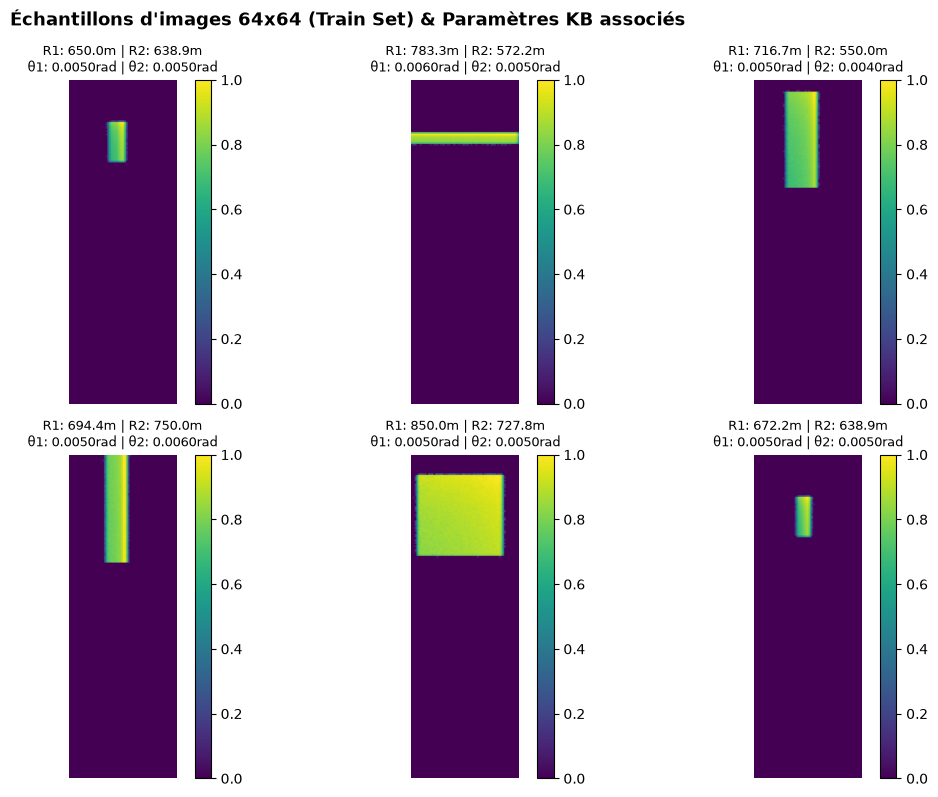

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
from torch.optim import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Force l'utilisation du CPU
device = torch.device('cpu')
print(f"Utilisation du device : {device}")

class McXtraceDataset(Dataset):
    """
    Dataset PyTorch pour lire les images PSD 64x64 de McXtrace
    et leurs paramètres associés (R1, R2, theta1, theta2).
    """
    def __init__(self, csv_file, root_dir):
        self.df = pd.read_csv(csv_file)
        self.root_dir = root_dir
        
        # Extraction des targets physiques brutes (N, 4)
        self.raw_targets = self.df[['R1', 'R2', 'theta1', 'theta2']].values.astype(np.float32)
        
        # Scaler pour normaliser les cibles
        self.target_scaler = StandardScaler()
        self.targets_normalized = None

    def fit_and_transform_targets(self, train_indices):
        """
        Calcul de la moyenne et de l'écart-type UNIQUEMENT sur le jeu de train
        pour éviter toute fuite de données (data leakage).
        """
        self.target_scaler.fit(self.raw_targets[train_indices])
        self.targets_normalized = self.target_scaler.transform(self.raw_targets)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        # Formatage du répertoire (ex: 1 -> '0001')
        folder_name = f"{int(row['id']):04d}"
        img_path = os.path.join(self.root_dir, folder_name, 'psd.dat')
        
        # Lecture du fichier .dat en ignorant les commentaires (#) McXtrace
        img = np.loadtxt(img_path, comments='#')
        
        # Pré-traitement d'image : transformation log pour l'intensité
        img = np.log1p(img)
        if img.max() > 0:
            img = img / img.max()  # Normalisation entre 0 et 1
            
        # Mise en forme Tensor : (H, W) -> (1, H, W)
        img_tensor = torch.tensor(img, dtype=torch.float32).unsqueeze(0)
        
        # Target normalisée
        target_tensor = torch.tensor(self.targets_normalized[idx], dtype=torch.float32)
        
        return img_tensor, target_tensor


# --- Chargement et découpage du dataset ---
full_dataset = McXtraceDataset(csv_file='training_dataset/parameters.csv', root_dir='training_dataset')

indices = list(range(len(full_dataset)))
train_idx, temp_idx = train_test_split(indices, test_size=0.2, random_state=42, shuffle=True)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, random_state=42, shuffle=True)

# Ajustement du scaler des targets sur le TRAIN uniquement
full_dataset.fit_and_transform_targets(train_idx)

# Création des Subsets PyTorch
train_dataset = Subset(full_dataset, train_idx)
val_dataset = Subset(full_dataset, val_idx)
test_dataset = Subset(full_dataset, test_idx)

# Instanciation des DataLoaders (CPU : num_workers=0 ou 2 est suffisant)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

print(f"Tailles des sets -> Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")


# --- AFFICHER QUELQUES IMAGES DU TRAIN DATASET ---

def plot_train_samples(dataloader, dataset_obj, num_samples=6):
    # Récupération d'un batch d'entraînement
    images_batch, targets_batch = next(iter(dataloader))
    
    # Dé-normalisation des cibles pour afficher les vraies valeurs physiques
    targets_physical = dataset_obj.target_scaler.inverse_transform(targets_batch.numpy())
    
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    axes = axes.flatten()
    
    for i in range(min(num_samples, len(images_batch))):
        img = images_batch[i].squeeze(0).numpy()  # Extrait la matrice (64, 64)
        r1, r2, t1, t2 = targets_physical[i]
        
        im = axes[i].imshow(img, cmap='viridis', origin='lower')
        axes[i].set_title(f"R1: {r1:.1f}m | R2: {r2:.1f}m\nθ1: {t1:.4f}rad | θ2: {t2:.4f}rad", fontsize=9)
        axes[i].axis('off')
        fig.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)
        
    plt.suptitle("Échantillons d'images 64x64 (Train Set) & Paramètres KB associés", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Affichage des 6 premiers faisceaux du batch
plot_train_samples(train_loader, full_dataset, num_samples=6)

# 2. Model Architecture

Here, we construct our PyTorch neural network architecture, defining the layers, activation functions, and pooling.

In [ ]:
class KBRegressionCNN(nn.Module):
    """
    CNN de rgression pour prdire (R1, R2, theta1, theta2)
    partir d'une image 2D de profil de faisceau X.
    """
    def __init__(self):
        super(KBRegressionCNN, self).__init__()
        
        # Extracteur de caractristiques visuelles
        self.features = nn.Sequential(
            # Bloc 1
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            # Bloc 2
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            # Bloc 3
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            # Global Average Pooling pour rduire la dpendance la taille stricte de l'image
            nn.AdaptiveAvgPool2d((4, 4))
        )
        
        # Tte de rgression (Fully Connected)
        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 128),
            nn.ReLU(),
            nn.Dropout(0.2),  # vite le sur-apprentissage (overfitting)
            nn.Linear(128, 4)  # Sortie = 4 paramtres (R1, R2, theta1, theta2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.regressor(x)
        return x

model = KBRegressionCNN().to(device)
print(model)

KBRegressionCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): AdaptiveAvgPool2d(output_size=(4, 4))
  )
  (regressor): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1):

# 3. Training and Visualization

First, we define the training modalities: optimizer, learning rate, number of epochs. Then, run the training loop (feedforward, loss calculation, backpropagation, and weight updates). Finally, we plot training and validation loss curves to monitor convergence and detect overfitting.

Époque [01/50] | Loss Train: 0.91303 | Loss Val: 0.86977
Époque [05/50] | Loss Train: 0.54550 | Loss Val: 0.61917
Époque [10/50] | Loss Train: 0.36014 | Loss Val: 0.36849
Époque [15/50] | Loss Train: 0.21322 | Loss Val: 0.20057
Époque [20/50] | Loss Train: 0.14669 | Loss Val: 0.14339
Époque [25/50] | Loss Train: 0.12893 | Loss Val: 0.09562
Époque [30/50] | Loss Train: 0.11199 | Loss Val: 0.08502
Époque [35/50] | Loss Train: 0.10850 | Loss Val: 0.07183
Époque [40/50] | Loss Train: 0.09812 | Loss Val: 0.05875
Époque [45/50] | Loss Train: 0.10240 | Loss Val: 0.07638
Époque [50/50] | Loss Train: 0.08826 | Loss Val: 0.06571


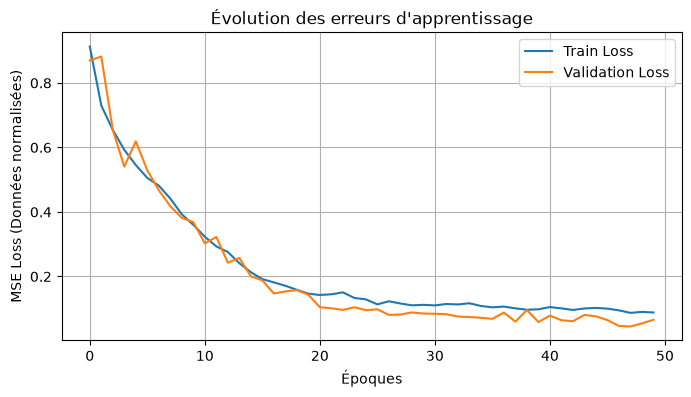

In [ ]:
criterion = nn.MSELoss()
optimizer = Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

epochs = 50
train_losses = []
val_losses = []

for epoch in range(epochs):
    # --- PHASE D'ENTRAÎNEMENT ---
    model.train()
    running_train_loss = 0.0
    
    for images, targets in train_loader:
        images, targets = images.to(device), targets.to(device)
        
        # Remise  zro des gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, targets)
        
        # Backward pass + Optimisation
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item() * images.size(0)
        
    epoch_train_loss = running_train_loss / len(train_dataset)
    train_losses.append(epoch_train_loss)
    
    # --- PHASE DE VALIDATION ---
    model.eval()
    running_val_loss = 0.0
    
    with torch.no_grad():
        for images, targets in val_loader:
            images, targets = images.to(device), targets.to(device)
            outputs = model(images)
            loss = criterion(outputs, targets)
            running_val_loss += loss.item() * images.size(0)
            
    epoch_val_loss = running_val_loss / len(val_dataset)
    val_losses.append(epoch_val_loss)
    
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Époque [{epoch+1:02d}/{epochs}] | Loss Train: {epoch_train_loss:.5f} | Loss Val: {epoch_val_loss:.5f}")

# --- Courbes d'apprentissage ---
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Époques')
plt.ylabel('MSE Loss (Données normalisées)')
plt.legend()
plt.title("Évolution des erreurs d'apprentissage")
plt.grid(True)
plt.show()

# 4. Testing and Evaluation

Finally, we evaluate the trained model on the unseen **Test** set to measure its real-world accuracy and generalization capacity.

In [7]:
model.eval()

predictions_norm = []
targets_norm = []

with torch.no_grad():
    for images, targets in test_loader:
        images = images.to(device)
        outputs = model(images)
        
        predictions_norm.append(outputs.cpu().numpy()[0])
        targets_norm.append(targets.numpy()[0])

predictions_norm = np.array(predictions_norm)
targets_norm = np.array(targets_norm)

# Dé-normalisation : Retour aux unités physiques réelles !
scaler = full_dataset.target_scaler
predictions_physical = scaler.inverse_transform(predictions_norm)
targets_physical = scaler.inverse_transform(targets_norm)

# Calcul des erreurs absolues moyennes (MAE) en unités physiques
mae_physical = np.mean(np.abs(predictions_physical - targets_physical), axis=0)

param_names = ['R1', 'R2', 'theta1', 'theta2']
print("\n--- ÉVALUATION SUR LE JEU DE TEST (Erreurs Moyennes Physiques) ---")
for name, mae in zip(param_names, mae_physical):
    print(f"Erreur moyenne (MAE) sur {name} : {mae:.6f}")

# --- Comparaison visuelle sur les 5 premiers exemples de test ---
df_res = pd.DataFrame()
for i, name in enumerate(param_names):
    df_res[f"{name}_Vrai"] = targets_physical[:5, i]
    df_res[f"{name}_Predit"] = predictions_physical[:5, i]

print("\nComparaison sur 5 échantillons de test :")
print(df_res.to_string())


--- ÉVALUATION SUR LE JEU DE TEST (Erreurs Moyennes Physiques) ---
Erreur moyenne (MAE) sur R1 : 13.780723
Erreur moyenne (MAE) sur R2 : 11.573204
Erreur moyenne (MAE) sur theta1 : 0.000145
Erreur moyenne (MAE) sur theta2 : 0.000164

Comparaison sur 5 échantillons de test :
      R1_Vrai   R1_Predit     R2_Vrai   R2_Predit  theta1_Vrai  theta1_Predit  theta2_Vrai  theta2_Predit
0  650.000000  658.652466  705.555542  685.326416        0.005       0.005055        0.005       0.005320
1  738.888916  759.432922  572.222229  586.873352        0.004       0.004323        0.005       0.005101
2  761.111084  758.417175  705.555542  738.978638        0.005       0.004894        0.006       0.006057
3  650.000000  668.874451  683.333313  681.702759        0.006       0.005981        0.004       0.004155
4  716.666687  723.354980  550.000000  552.494751        0.005       0.004973        0.006       0.006111


# 5. Visualization of Test Results

This cell plots the usual curves used to evaluate the results of a regression problem. This allows us to assess how the neural network predictions vary across the dataset.

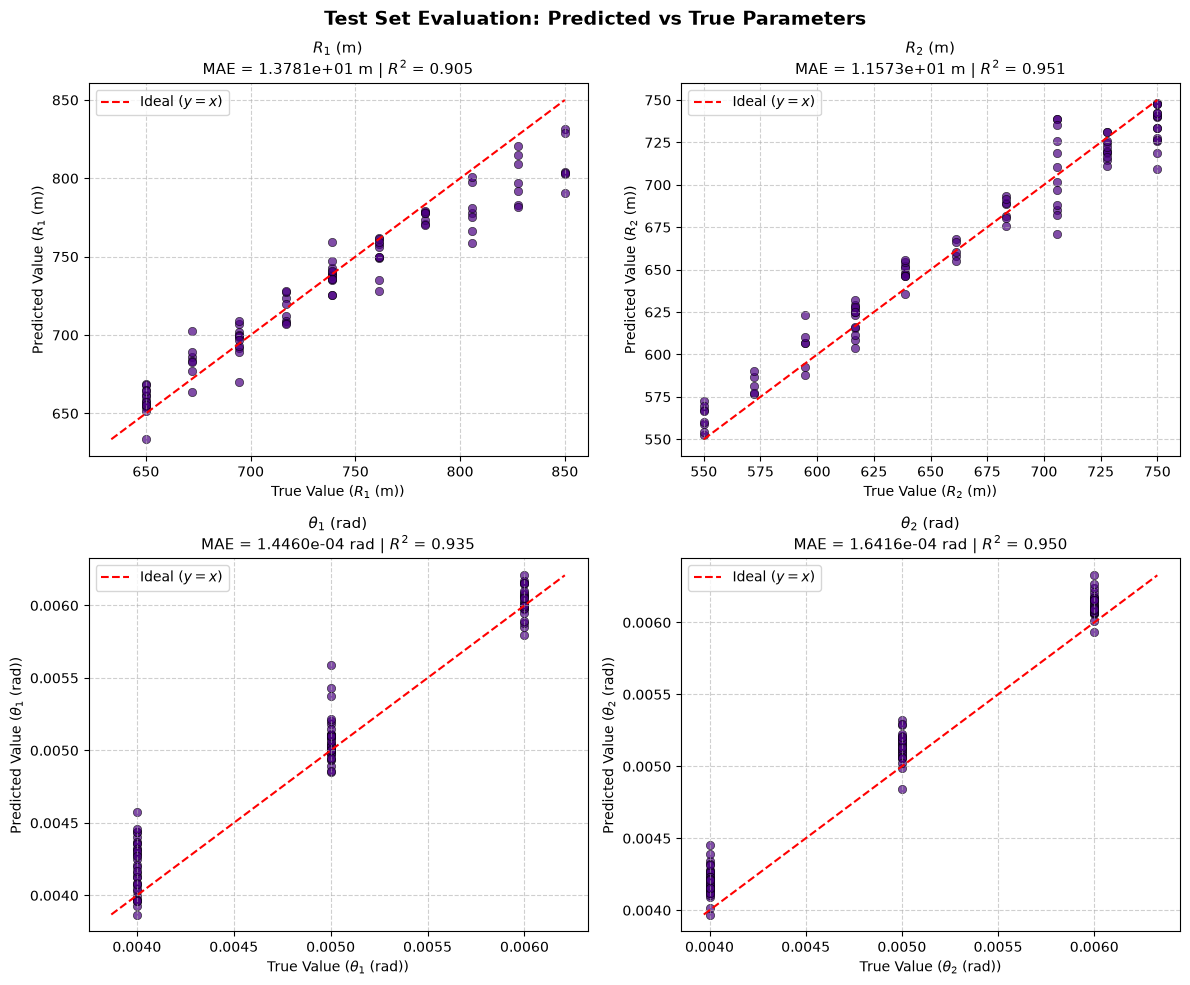

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# 1. Set model to evaluation mode
model.eval()

predictions_norm = []
targets_norm = []

# 2. Inference on the TEST set
with torch.no_grad():
    for images, targets in test_loader:
        images = images.to(device)
        outputs = model(images)
        
        predictions_norm.append(outputs.cpu().numpy())
        targets_norm.append(targets.numpy())

# Concatenate results
predictions_norm = np.vstack(predictions_norm)
targets_norm = np.vstack(targets_norm)

# 3. Denormalization (back to true physical units)
scaler = full_dataset.target_scaler
y_pred = scaler.inverse_transform(predictions_norm)
y_true = scaler.inverse_transform(targets_norm)

# 4. Plot y_predict vs y_true
param_names = ['$R_1$ (m)', '$R_2$ (m)', '$\\theta_1$ (rad)', '$\\theta_2$ (rad)']
units = ['m', 'm', 'rad', 'rad']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i in range(4):
    ax = axes[i]
    
    # Scatter plot
    ax.scatter(y_true[:, i], y_pred[:, i], alpha=0.7, color='indigo', edgecolors='k', linewidth=0.5)
    
    # Ideal identity line y = x
    min_val = min(y_true[:, i].min(), y_pred[:, i].min())
    max_val = max(y_true[:, i].max(), y_pred[:, i].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal ($y=x$)')
    
    # Error metrics (MAE and R²)
    mae = np.mean(np.abs(y_pred[:, i] - y_true[:, i]))
    r2 = 1 - (np.sum((y_true[:, i] - y_pred[:, i])**2) / np.sum((y_true[:, i] - np.mean(y_true[:, i]))**2))
    
    ax.set_title(f"{param_names[i]}\nMAE = {mae:.4e} {units[i]} | $R^2$ = {r2:.3f}", fontsize=11)
    ax.set_xlabel(f"True Value ({param_names[i]})")
    ax.set_ylabel(f"Predicted Value ({param_names[i]})")
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(loc='upper left')

plt.suptitle("Test Set Evaluation: Predicted vs True Parameters", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 6. One Shot Test

This cell is designed to evaluate the model performances on new runs of McXTrace simulation, independant from the dataset generation.

In [10]:
import os
import numpy as np
import pandas as pd
import torch

# 1. Chemin vers ton nouveau fichier psd.dat
new_run_dir = 'Test_KB_20260924_160421'
dat_path = os.path.join(new_run_dir, 'psd.dat')

# Check de l'existence du fichier
if not os.path.exists(dat_path):
    raise FileNotFoundError(f"Fichier non trouvé : {dat_path}")

# 2. Chargement et prétraitement de l'image (identique au Dataset)
img = np.loadtxt(dat_path, comments='#')

# Prétraitement log + min-max
img_prep = np.log1p(img)
if img_prep.max() > 0:
    img_prep = img_prep / img_prep.max()

# Conversion en Tensor PyTorch : shape (1, 1, 64, 64) -> (Batch, Channel, Height, Width)
img_tensor = torch.tensor(img_prep, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

# 3. Inférence avec le modèle entraîné
model.eval()
with torch.no_grad():
    pred_normalized = model(img_tensor).cpu().numpy()

# 4. Dé-normalisation pour retrouver les valeurs physiques (R1, R2, theta1, theta2)
scaler = full_dataset.target_scaler
pred_physical = scaler.inverse_transform(pred_normalized)[0]

# 5. Affichage propre des résultats sous forme de DataFrame
param_names = ['R1 (m)', 'R2 (m)', 'theta1 (rad)', 'theta2 (rad)']
df_prediction = pd.DataFrame([pred_physical], columns=param_names)

print(f"--- PRÉDICTION POUR LA SIMULATION {new_run_dir} ---")
print(df_prediction.to_string(index=False))

--- PRÉDICTION POUR LA SIMULATION Test_KB_20260924_160421 ---
    R1 (m)     R2 (m)  theta1 (rad)  theta2 (rad)
660.136047 611.164185      0.005077      0.004818
